Cuaderno 3: Predicción (Uso del Modelo)

Este es el último cuaderno, encargado de poner a prueba todo lo construido. Importamos las librerías básicas de manipulación de datos y establecemos las rutas absolutas para cargar el histórico limpio y el modelo que ya entrenamos.

In [1]:
import os
import pandas as pd
import numpy as np
import joblib

print("Inicializando entorno de simulación (Backtesting)...")

BASE_DIR = os.path.abspath('')
DATA_DIR = os.path.join(BASE_DIR, "data", "raw")
MODELS_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "data", "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

SYMBOL = "EURUSD"
RUTA_DATOS = os.path.join(DATA_DIR, f"{SYMBOL}_M5.parquet")
RUTA_MODELO = os.path.join(MODELS_DIR, f"{SYMBOL}_M5_scalper.joblib")
RUTA_REPORTE = os.path.join(RESULTS_DIR, "historial_trades_oos.csv")

print(f"Ruta de datos objetivo: {RUTA_DATOS}")
print(f"Ruta de modelo a evaluar: {RUTA_MODELO}")
print(f"Ruta de exportación de resultados: {RUTA_REPORTE}")

Inicializando entorno de simulación (Backtesting)...
Ruta de datos objetivo: c:\Users\juand\OneDrive\Documentos\ECHELONIX\NO SUBIR\vscode\CUADERNOS JUPYTER\data\raw\EURUSD_M5.parquet
Ruta de modelo a evaluar: c:\Users\juand\OneDrive\Documentos\ECHELONIX\NO SUBIR\vscode\CUADERNOS JUPYTER\models\EURUSD_M5_scalper.joblib
Ruta de exportación de resultados: c:\Users\juand\OneDrive\Documentos\ECHELONIX\NO SUBIR\vscode\CUADERNOS JUPYTER\data\results\historial_trades_oos.csv


Cargamos el archivo Parquet y el modelo .joblib. Para esta simulación de prueba en avance (Walk-Forward), aislaremos rigurosamente el periodo "Out-of-Sample" (OOS), que comprende todo el año 2025, garantizando que el modelo opere sobre datos completamente desconocidos para él.

In [2]:
print("Cargando el modelo XGBoost desde el almacenamiento local...")
modelo_ia = joblib.load(RUTA_MODELO)
print("Modelo cargado y listo para inferencia.")

print("Cargando base de datos histórica Parquet...")
df_par = pd.read_parquet(RUTA_DATOS)
print(f"Base de datos cargada. Tamaño total: {len(df_par)} velas.")

print("Aislando el periodo Out-of-Sample (OOS) para evaluación: 2025-01-01 al 2025-12-31...")
df_oos = df_par.loc['2025-01-01':'2025-12-31'].copy()
print(f"Conjunto de validación OOS aislado con éxito. Total de velas a simular: {len(df_oos)}")

Cargando el modelo XGBoost desde el almacenamiento local...
Modelo cargado y listo para inferencia.
Cargando base de datos histórica Parquet...
Base de datos cargada. Tamaño total: 208631 velas.
Aislando el periodo Out-of-Sample (OOS) para evaluación: 2025-01-01 al 2025-12-31...
Conjunto de validación OOS aislado con éxito. Total de velas a simular: 31080


Definimos la lógica central de la estrategia. Esta clase tomará las características de cada vela, se las enviará al modelo XGBoost para obtener una probabilidad de éxito, y si las condiciones estadísticas (Z-Score, Volumen y ATR) y la probabilidad superan nuestros umbrales de rigor, emitirá una señal de compra o venta calculando sus respectivos niveles de Stop Loss y Take Profit.

In [3]:
class ScalpingEURUSD:
    def __init__(self, modelo, umbral_zscore=1.8, tp_runner_rr=5.0):
        self.symbol = SYMBOL
        self.umbral_zscore = umbral_zscore
        self.tp_runner_rr = tp_runner_rr
        self.tp_parcial_rr = 0.5
        self.modelo = modelo
        print(f"Estrategia inicializada - RR Parcial: {self.tp_parcial_rr} | RR Runner: {self.tp_runner_rr}")

    def evaluar_mercado(self, ultima_barra):
        cols_features = [
            'z_score', 'dist_ema288', 'vol_spike', 
            'lower_wick_ratio', 'upper_wick_ratio', 'body_ratio'
        ]
        
        features = ultima_barra[cols_features].values.reshape(1, -1)
        probabilidades = self.modelo.predict_proba(features)[0]
        prob_exito = probabilidades[1]
        
        senal = 0
        tp_parcial = 0.0
        tp_runner = 0.0
        sl = 0.0
        
        z_val = ultima_barra['z_score']
        atr_val = ultima_barra['atr']
        vol_val = ultima_barra['vol_spike']
        
        if ultima_barra['is_killzone'] == 1 and prob_exito >= 0.68 and atr_val > 0.0005:
            if z_val < -0.6 and vol_val > 1.1:
                senal = 1
            elif z_val > 0.6 and vol_val > 1.1:
                senal = -1
                
        if senal == 1:
            sl = ultima_barra['close'] - (atr_val * 0.8)
            riesgo = ultima_barra['close'] - sl
            tp_parcial = ultima_barra['close'] + (riesgo * self.tp_parcial_rr)
            tp_runner = ultima_barra['close'] + (riesgo * self.tp_runner_rr)
        elif senal == -1:
            sl = ultima_barra['close'] + (atr_val * 0.8)
            riesgo = sl - ultima_barra['close']
            tp_parcial = ultima_barra['close'] - (riesgo * self.tp_parcial_rr)
            tp_runner = ultima_barra['close'] - (riesgo * self.tp_runner_rr)
            
        return {
            'senal': senal,
            'tp_parcial': tp_parcial,
            'tp_runner': tp_runner,
            'sl': sl,
            'prob': prob_exito
        }

Construimos el motor de Backtesting. Este componente recorrerá la serie temporal vela por vela, gestionando el capital inicial, calculando el tamaño de las posiciones según el riesgo permitido por operación, aplicando comisiones y midiendo la excursión del precio (MAE y MFE) para determinar el resultado financiero exacto de la estrategia a lo largo del año.

In [4]:
class BacktestEngine:
    def __init__(self, estrategia, capital_inicial=10000.0, comision=7.0, riesgo_por_trade=0.005):
        self.estrategia = estrategia
        self.balance = capital_inicial
        self.balance_pico = capital_inicial
        self.max_drawdown_pct = 0.0
        self.comision = comision
        self.riesgo_por_trade = riesgo_por_trade
        self.historial = []
        print(f"Motor de Backtest configurado - Capital: ${self.balance} | Riesgo/Trade: {self.riesgo_por_trade*100}%")

    def ejecutar(self, df_test, spread_real=0.00002):
        print("Iniciando motor de simulación iterativa...")
        posicion = 0
        precio_entrada = 0.0
        fecha_entrada = None
        tp_actual = 0.0
        sl_actual = 0.0
        parcial_tomado = False
        pnl_parcial_acumulado = 0.0
        precio_be = 0.0
        mfe_max = 0.0
        mae_max = 0.0
        nocional_trade = 0.0
        
        precios = df_test['close'].values
        highs = df_test['high'].values
        lows = df_test['low'].values
        fechas = df_test.index.values

        for i in range(len(df_test)):
            precio_actual = precios[i]
            high_actual = highs[i]
            low_actual = lows[i]
            fecha_actual = fechas[i]

            if posicion != 0:
                if posicion == 1:
                    exc_fav = high_actual - precio_entrada
                    exc_adv = precio_entrada - low_actual
                else:
                    exc_fav = precio_entrada - low_actual
                    exc_adv = high_actual - precio_entrada
                    
                if exc_fav > mfe_max: mfe_max = exc_fav
                if exc_adv > mae_max: mae_max = exc_adv

                distancia_riesgo = abs(precio_entrada - precio_be)
                
                if not parcial_tomado:
                    if exc_fav >= distancia_riesgo * 1.0:
                        if posicion == 1:
                            precio_parcial = precio_entrada + distancia_riesgo
                            pnl_parcial = ((precio_parcial - spread_real - precio_entrada) / precio_entrada) * nocional_trade * 0.5
                        else:
                            precio_parcial = precio_entrada - distancia_riesgo
                            pnl_parcial = ((precio_entrada - (precio_parcial + spread_real)) / precio_entrada) * nocional_trade * 0.5
                        
                        self.balance += pnl_parcial
                        pnl_parcial_acumulado = pnl_parcial
                        parcial_tomado = True
                        
                        if self.balance > self.balance_pico:
                            self.balance_pico = self.balance
                        dd_actual = ((self.balance_pico - self.balance) / self.balance_pico) * 100
                        if dd_actual > self.max_drawdown_pct:
                            self.max_drawdown_pct = dd_actual

            if posicion == 0:
                ultima_barra = df_test.iloc[i]
                evaluacion = self.estrategia.evaluar_mercado(ultima_barra)

                if evaluacion['senal'] != 0:
                    posicion = evaluacion['senal']
                    precio_entrada = precio_actual + (spread_real if posicion == 1 else -spread_real)
                    tp_actual = evaluacion['tp_runner'] 
                    sl_actual = evaluacion['sl']
                    precio_be = evaluacion['sl']
                    fecha_entrada = fecha_actual
                    parcial_tomado = False
                    pnl_parcial_acumulado = 0.0
                    mfe_max = 0.0
                    mae_max = 0.0

                    distancia_riesgo_abs = abs(precio_entrada - sl_actual)
                    if distancia_riesgo_abs > 0:
                        nocional_trade = (self.balance * self.riesgo_por_trade) / (distancia_riesgo_abs / precio_entrada)
                    else:
                        nocional_trade = 0.0

                    comision_trade = (nocional_trade / 100000.0) * self.comision
                    self.balance -= comision_trade
                    
                    tipo_str = "COMPRA" if posicion == 1 else "VENTA"
                    print(f"[{fecha_entrada}] APERTURA {tipo_str} | Precio: {precio_entrada:.5f} | Probabilidad IA: {evaluacion['prob']*100:.1f}%")

            elif posicion != 0:
                cond_tp = (high_actual >= tp_actual) if posicion == 1 else (low_actual <= tp_actual)
                cond_sl = (low_actual <= sl_actual) if posicion == 1 else (high_actual >= sl_actual)

                if cond_tp or cond_sl:
                    if cond_sl and cond_tp:
                        precio_salida = sl_actual
                        motivo = "Stop_Loss"
                    elif cond_tp:
                        precio_salida = tp_actual
                        motivo = "Take_Profit"
                    else:
                        precio_salida = sl_actual
                        motivo = "Stop_Loss"

                    multiplicador_vol = 0.5 if parcial_tomado else 1.0

                    if posicion == 1:
                        pnl_final = ((precio_salida - spread_real - precio_entrada) / precio_entrada) * nocional_trade * multiplicador_vol
                    else:
                        pnl_final = ((precio_entrada - (precio_salida + spread_real)) / precio_entrada) * nocional_trade * multiplicador_vol

                    self.balance += pnl_final
                    pnl_total_trade = pnl_parcial_acumulado + pnl_final
                    
                    if self.balance > self.balance_pico:
                        self.balance_pico = self.balance
                    dd_actual = ((self.balance_pico - self.balance) / self.balance_pico) * 100
                    if dd_actual > self.max_drawdown_pct:
                        self.max_drawdown_pct = dd_actual
                    
                    motivo_print = motivo
                    if motivo == "Stop_Loss" and parcial_tomado:
                        motivo_print = "BE_Matematico"

                    print(f"[{fecha_actual}] CIERRE por {motivo_print} | PnL Total: ${pnl_total_trade:.2f} | Balance Acumulado: ${self.balance:.2f} | DD: {dd_actual:.2f}%")
                    print("-" * 60)

                    self.historial.append({
                        "Operacion": "Buy" if posicion == 1 else "Sell",
                        "Entrada": fecha_entrada,
                        "Salida_Fecha": fecha_actual,
                        "Motivo": motivo_print,
                        "PnL_Total": round(pnl_total_trade, 2),
                        "Balance": round(self.balance, 2),
                        "Drawdown_Act": round(dd_actual, 2),
                        "MFE_Pips": round(mfe_max * 10000, 1),
                        "MAE_Pips": round(mae_max * 10000, 1),
                        "Parcial_Hit": parcial_tomado
                    })

                    posicion = 0
                    mfe_max = 0.0
                    mae_max = 0.0

        print("Simulación concluida.")
        return self.balance, self.max_drawdown_pct, self.historial

Ejecutamos el entorno simulado y condensamos las métricas extraídas en un reporte analítico. Este bloque imprimirá el desempeño de la inteligencia artificial, calculando la rentabilidad final neta, el Drawdown máximo alcanzado y la precisión operativa a lo largo de las pruebas. Además, exporta el libro de transacciones a un archivo CSV.

In [5]:
print("\n" + "="*80)
print(" INICIANDO TELEMETRÍA DE EJECUCIÓN OOS ".center(80, "="))
print("="*80 + "\n")

estrategia_ia = ScalpingEURUSD(modelo=modelo_ia, tp_runner_rr=5.0)
motor_backtest = BacktestEngine(estrategia=estrategia_ia, capital_inicial=10000.0, riesgo_por_trade=0.007)

balance_final_oos, max_drawdown, historial_operaciones = motor_backtest.ejecutar(df_oos, spread_real=0.00002)

print(f"\nExportando historial de operaciones a: {RUTA_REPORTE}")
df_trades = pd.DataFrame(historial_operaciones)
if not df_trades.empty:
    df_trades.to_csv(RUTA_REPORTE, index=False)
    
dias_oos = max(1, len(df_oos) / 288)

print("\n======= REPORTE MÉTRICO AVANZADO OOS =======")
print(f"Balance Final OOS: {balance_final_oos:.2f} USD")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Frecuencia Operativa: {len(historial_operaciones)/dias_oos:.2f} trades/día")

if not df_trades.empty:
    total_trades = len(df_trades)
    
    if 'Parcial_Hit' in df_trades.columns:
        parciales = len(df_trades[df_trades['Parcial_Hit'] == True])
        win_rate_real = (parciales / total_trades) * 100 if total_trades > 0 else 0
        print(f"Precisión de Entrada (Parcial Asegurado): {win_rate_real:.2f}% ({parciales}/{total_trades} trades)")
    
    avg_mfe = df_trades['MFE_Pips'].mean()
    avg_mae = df_trades['MAE_Pips'].mean()
    
    print(f"Promedio MFE (Excursión a favor): {avg_mfe:.1f} pips")
    print(f"Promedio MAE (Excursión en contra): {avg_mae:.1f} pips")
    print("============================================")
else:
    print("El modelo no generó operaciones durante el periodo OOS bajo los parámetros actuales.")
    print("============================================")


==================== INICIANDO TELEMETRÍA DE EJECUCIÓN OOS =====================

Estrategia inicializada - RR Parcial: 0.5 | RR Runner: 5.0
Motor de Backtest configurado - Capital: $10000.0 | Riesgo/Trade: 0.7000000000000001%
Iniciando motor de simulación iterativa...
[2025-01-02T08:00:00.000] APERTURA COMPRA | Precio: 1.03632 | Probabilidad IA: 70.3%
[2025-01-02T10:15:00.000] CIERRE por Stop_Loss | PnL Total: $-71.45 | Balance Acumulado: $9923.28 | DD: 0.77%
------------------------------------------------------------
[2025-01-03T07:05:00.000] APERTURA COMPRA | Precio: 1.02679 | Probabilidad IA: 68.1%
[2025-01-03T11:20:00.000] CIERRE por Take_Profit | PnL Total: $198.81 | Balance Acumulado: $10113.48 | DD: 0.00%
------------------------------------------------------------
[2025-01-06T07:05:00.000] APERTURA COMPRA | Precio: 1.03147 | Probabilidad IA: 72.0%
[2025-01-06T07:55:00.000] CIERRE por Stop_Loss | PnL Total: $-73.93 | Balance Acumulado: $10028.24 | DD: 0.84%
------------------

En esta celda vamos a leer el archivo CSV generado por el Backtest y a calcular las métricas estadísticas clave del sistema de trading. Calcularemos el Profit Factor (relación entre ganancias y pérdidas brutas), el porcentaje de operaciones ganadoras reales (más allá de asegurar el parcial) y el retorno total sobre el capital inicial.

In [6]:
print("Cargando historial de operaciones para análisis estadístico...")
df_trades = pd.read_csv(RUTA_REPORTE)

# Convertir fechas para su manipulación
df_trades['Entrada'] = pd.to_datetime(df_trades['Entrada'])
df_trades['Salida_Fecha'] = pd.to_datetime(df_trades['Salida_Fecha'])

# Cálculos estadísticos
capital_inicial = 10000.0
balance_final = df_trades['Balance'].iloc[-1]
beneficio_neto = balance_final - capital_inicial
rendimiento_pct = (beneficio_neto / capital_inicial) * 100

# Ganancias y pérdidas brutas
trades_ganadores = df_trades[df_trades['PnL_Total'] > 0]
trades_perdedores = df_trades[df_trades['PnL_Total'] <= 0]

ganancia_bruta = trades_ganadores['PnL_Total'].sum()
perdida_bruta = abs(trades_perdedores['PnL_Total'].sum())

# Profit Factor
profit_factor = ganancia_bruta / perdida_bruta if perdida_bruta > 0 else float('inf')

# Win Rate Real (Trades que terminaron en positivo)
total_trades = len(df_trades)
win_rate = (len(trades_ganadores) / total_trades) * 100

# Drawdown Máximo registrado en el historial
max_dd_registrado = df_trades['Drawdown_Act'].max()

# Promedios
promedio_ganancia = trades_ganadores['PnL_Total'].mean() if not trades_ganadores.empty else 0
promedio_perdida = trades_perdedores['PnL_Total'].mean() if not trades_perdedores.empty else 0
ratio_riesgo_beneficio = abs(promedio_ganancia / promedio_perdida) if promedio_perdida != 0 else 0

print("\n" + "="*50)
print(" ESTADÍSTICAS AVANZADAS DEL SISTEMA ".center(50))
print("="*50)
print(f"Capital Inicial: ${capital_inicial:.2f}")
print(f"Balance Final: ${balance_final:.2f}")
print(f"Beneficio Neto: ${beneficio_neto:.2f}")
print(f"Rendimiento Total: {rendimiento_pct:.2f}%")
print("-" * 50)
print(f"Total Operaciones: {total_trades}")
print(f"Win Rate (Trades Rentables): {win_rate:.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Drawdown Máximo: {max_dd_registrado:.2f}%")
print("-" * 50)
print(f"Promedio Trade Ganador: ${promedio_ganancia:.2f}")
print(f"Promedio Trade Perdedor: ${promedio_perdida:.2f}")
print(f"Ratio Riesgo/Beneficio Promedio: {ratio_riesgo_beneficio:.2f}")
print("="*50)

Cargando historial de operaciones para análisis estadístico...

        ESTADÍSTICAS AVANZADAS DEL SISTEMA        
Capital Inicial: $10000.00
Balance Final: $10428.61
Beneficio Neto: $428.61
Rendimiento Total: 4.29%
--------------------------------------------------
Total Operaciones: 174
Win Rate (Trades Rentables): 20.69%
Profit Factor: 1.23
Drawdown Máximo: 12.80%
--------------------------------------------------
Promedio Trade Ganador: $219.88
Promedio Trade Perdedor: $-46.52
Ratio Riesgo/Beneficio Promedio: 4.73


Finalmente, utilizaremos matplotlib para generar una representación visual del desempeño de la estrategia. Crearemos un gráfico compuesto: en la parte superior veremos la evolución de la Curva de Capital (Equity Curve) y en la parte inferior el Drawdown dinámico para observar los periodos de mayor estrés financiero.

Generando gráficos de rendimiento...


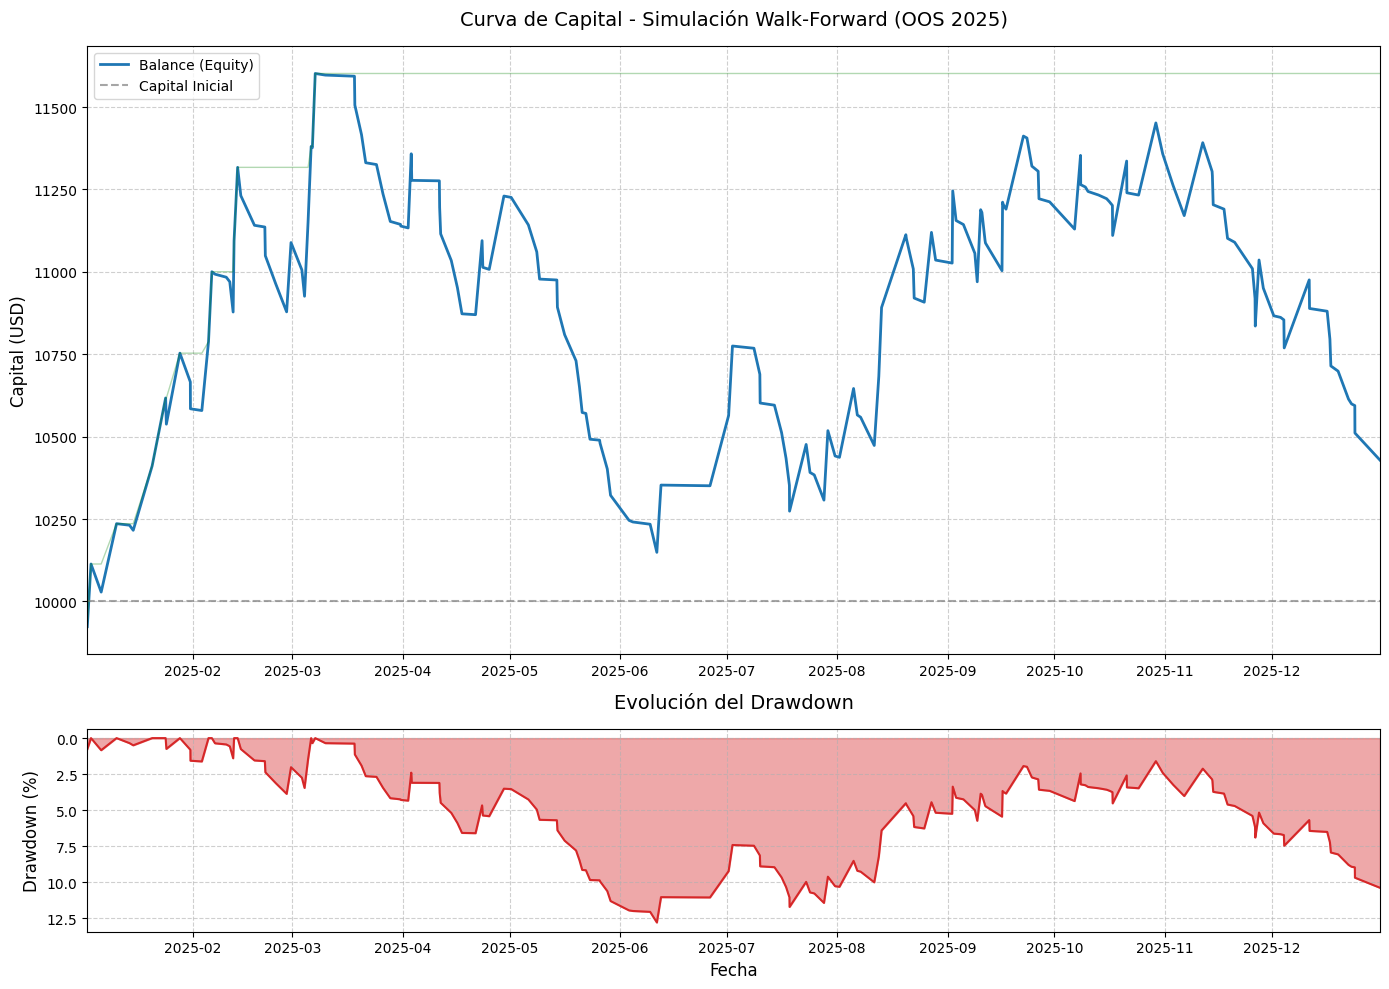

In [7]:
import matplotlib.pyplot as plt

print("Generando gráficos de rendimiento...")

# Configurar el estilo de la gráfica
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Gráfico 1: Curva de Capital (Equity Curve)
ax1.plot(df_trades['Salida_Fecha'], df_trades['Balance'], color='#1f77b4', linewidth=2, label='Balance (Equity)')
ax1.axhline(y=capital_inicial, color='gray', linestyle='--', alpha=0.7, label='Capital Inicial')
ax1.set_title('Curva de Capital - Simulación Walk-Forward (OOS 2025)', fontsize=14, pad=15)
ax1.set_ylabel('Capital (USD)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')
ax1.margins(x=0)

# Resaltar puntos de máximo balance (Nuevos máximos)
balance_picos = df_trades['Balance'].cummax()
ax1.plot(df_trades['Salida_Fecha'], balance_picos, color='green', alpha=0.3, linewidth=1, label='High Water Mark')

# Gráfico 2: Drawdown
ax2.fill_between(df_trades['Salida_Fecha'], df_trades['Drawdown_Act'], 0, color='#d62728', alpha=0.4)
ax2.plot(df_trades['Salida_Fecha'], df_trades['Drawdown_Act'], color='#d62728', linewidth=1.5)
ax2.set_title('Evolución del Drawdown', fontsize=14, pad=15)
ax2.set_ylabel('Drawdown (%)', fontsize=12)
ax2.set_xlabel('Fecha', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.margins(x=0)

# Invertir el eje Y del Drawdown para que se vea como caída
ax2.invert_yaxis()

plt.tight_layout()
plt.show()